In [1]:
import sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.colors import to_rgba

from resources.schemas.config_experiment import *
from pgmpy.causal_discovery import HillClimbSearch
from bootstrap import NetworkBootstrap, hillclimb_network_edge_fn

DATA_PATH = "../data/grinding_normalized.csv"
RANDOM_STATE = 42

## Data reading

In [3]:
df_model = pd.read_csv(DATA_PATH)
df_model.head()

,ids,doi,Type of Synthesis,Formula,API,Coformer,Part of Ratio API,Part of Ratio Coformer,Amount of API,Amount of Coformer,...,Frequency Unit,Mixing Time,Mixing Time Unit,Mixing Temperature,Mixing Temperature Unit,Drying Time,Drying Time Unit,Drying Temperature,Drying Temperature Unit,Temperature of Drying (numeric)
0,id0007,10.3390/pharmaceutics13040546,liquid-assisted grinding,MTZ-EG,metronidazole,ethyl gallate,"[0.5, 1.5)","[0.5, 1.5)","[21.2, 33.3)","[21.1, 33.8)",...,hz,"[30.0, 40.0)",min,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
1,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[0.5, 1.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
2,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[0.5, 1.5)","[1.5, 2.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
3,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,CBZ-HQ,carbamazepine,hydroquinone,"[1.5, 2.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED
4,id0008,10.1007/s10870-011-0147-y,liquid-assisted grinding,PA-HQ,piracetam,hydroquinone,"[0.5, 1.5)","[0.5, 1.5)",NOT_DETECTED,NOT_DETECTED,...,hz,"[15.0, 20.0)",min,"[30.0, inf)",c,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED,NOT_DETECTED


In [6]:
def plot_graph(graph, node_color="#ffb703", random_state_addition=989, title=''):
    fig, ax = plt.subplots(figsize=(11, 9))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE+random_state_addition, k=0.9, method='energy')

    nx.draw_networkx_nodes(graph, pos, node_color=node_color, node_size=2000, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.7)
    ax.set_title(title)
    ax.axis("off")
    
    plt.tight_layout()
    plt.show()


def plot_bootstrap_graph(edges_table, node_color="#ffb703", edge_color="#264653",
                          min_frequency=0.0, random_state_addition=989, title=""):
    graph = nx.Graph()
    for _, row in edges_table.iterrows():
        if row["frequency"] >= min_frequency:
            graph.add_edge(row["V1"], row["V2"], weight=row["frequency"])

    fig, ax = plt.subplots(figsize=(11, 9))
    pos = nx.spring_layout(graph, seed=RANDOM_STATE + random_state_addition, k=50000, weight="weight", method="energy")

    weights = [graph[u][v]["weight"] for u, v in graph.edges()]
    widths = [1 + 6 * w for w in weights]
    colors = [to_rgba(edge_color, alpha=0.15 + 0.8 * w) for w in weights]

    nx.draw_networkx_nodes(graph, pos, node_color=node_color, node_size=2000, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(graph, pos, ax=ax, width=widths, edge_color=colors)
    ax.set_title(title)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

## HillClimb search

In [6]:
hc_ll = HillClimbSearch(scoring_method='ll-d', max_indegree=1)
hc_ll.fit(df_model[VARIABLE_COLUMNS])
graph_ll = hc_ll.causal_graph_.to_undirected()

hc_bic = HillClimbSearch(scoring_method='bic-d', max_indegree=1)
hc_bic.fit(df_model[VARIABLE_COLUMNS])
graph_bic = hc_bic.causal_graph_.to_undirected()

hc_aic = HillClimbSearch(scoring_method='aic-d', max_indegree=1)
hc_aic.fit(df_model[VARIABLE_COLUMNS])
graph_aic = hc_aic.causal_graph_.to_undirected()

  0%|          | 16/1000000 [00:01<28:28:30,  9.75it/s]


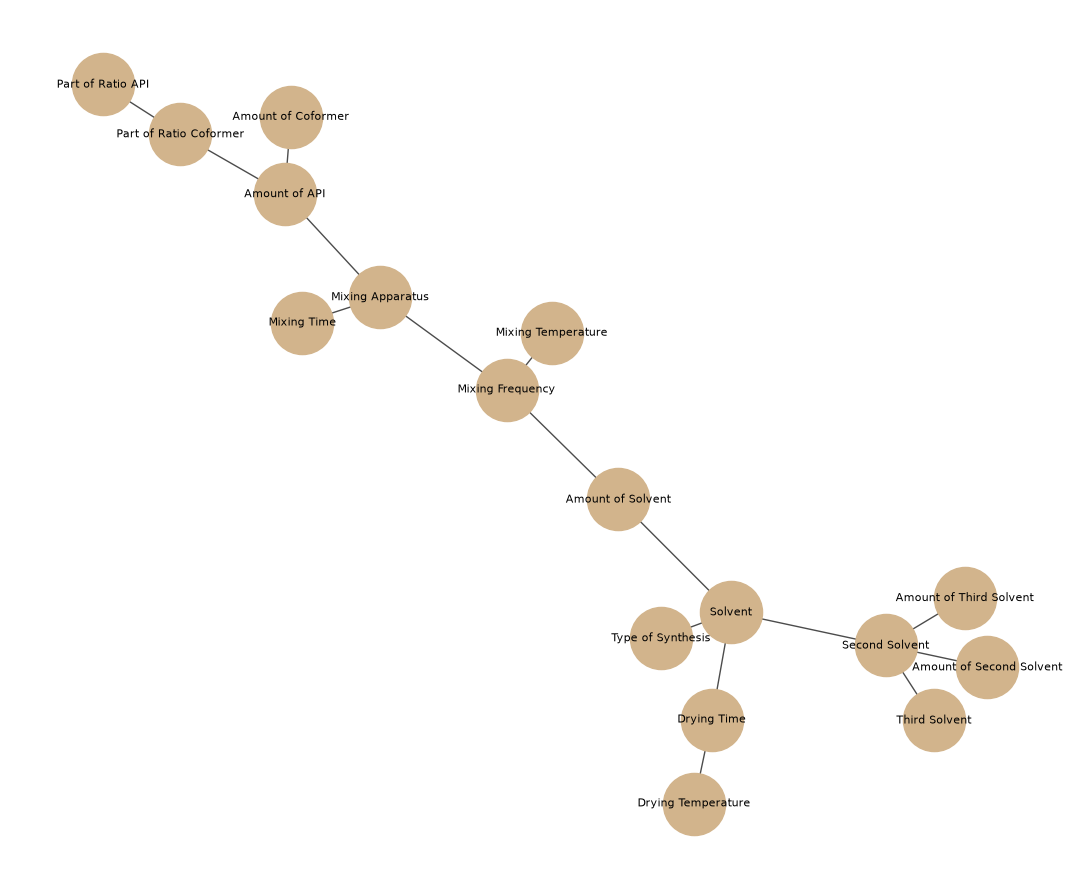

In [12]:
plot_graph(graph_ll, node_color="tan", random_state_addition=88)

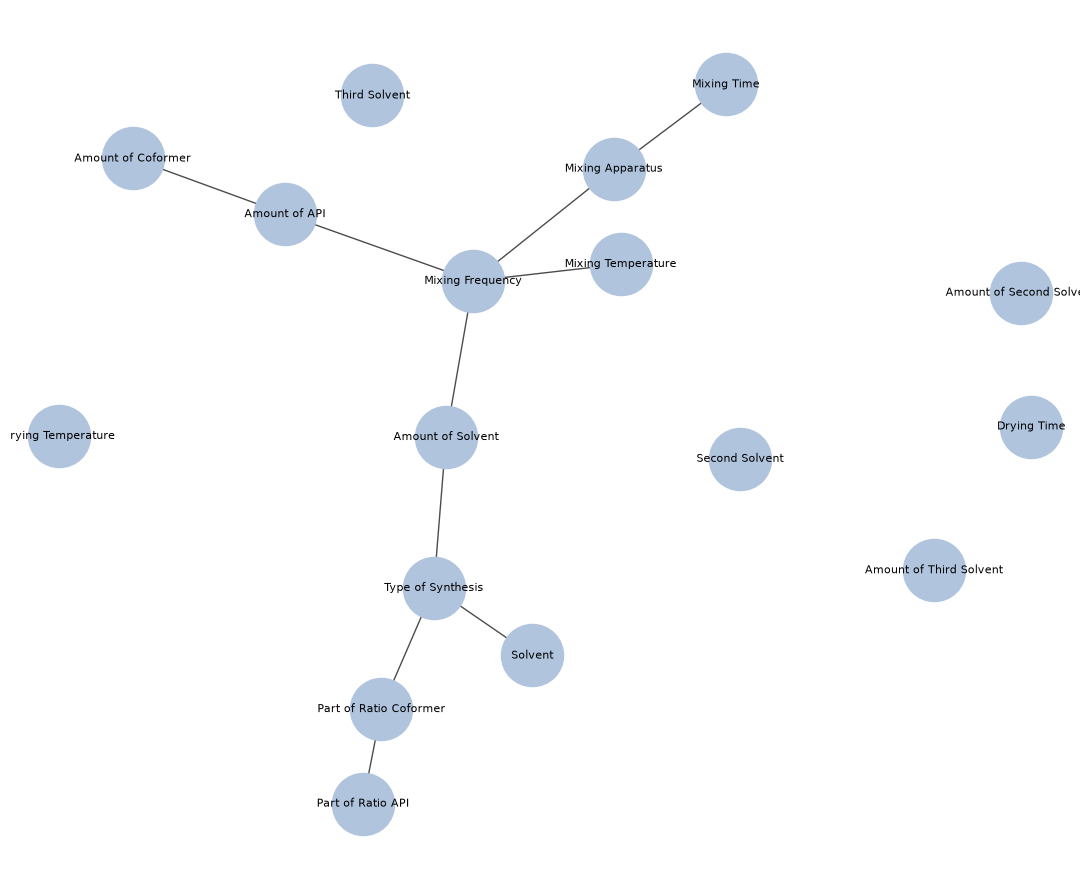

In [13]:
plot_graph(graph_bic, node_color="LightSteelBlue")

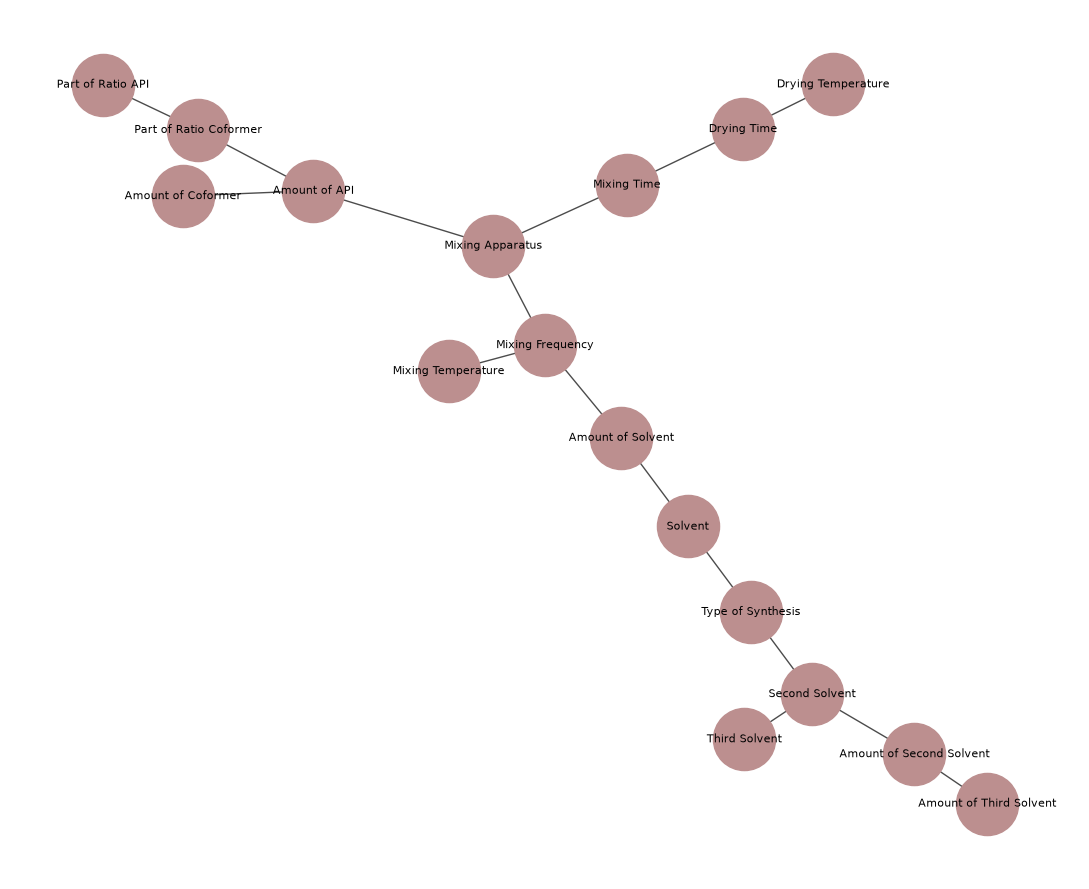

In [34]:
plot_graph(graph_aic, node_color="rosybrown", random_state_addition=2)

## Bootstrap: HillClimb with LogLik

In [ ]:
N_ITERATIONS_LL = 100

hc_ll_fit_fn = hillclimb_network_edge_fn(VARIABLE_COLUMNS, criterion='ll-d', max_parents=1)
hc_ll_edges_table = NetworkBootstrap(hc_ll_fit_fn, n_iterations=N_ITERATIONS_LL).run(df_model)

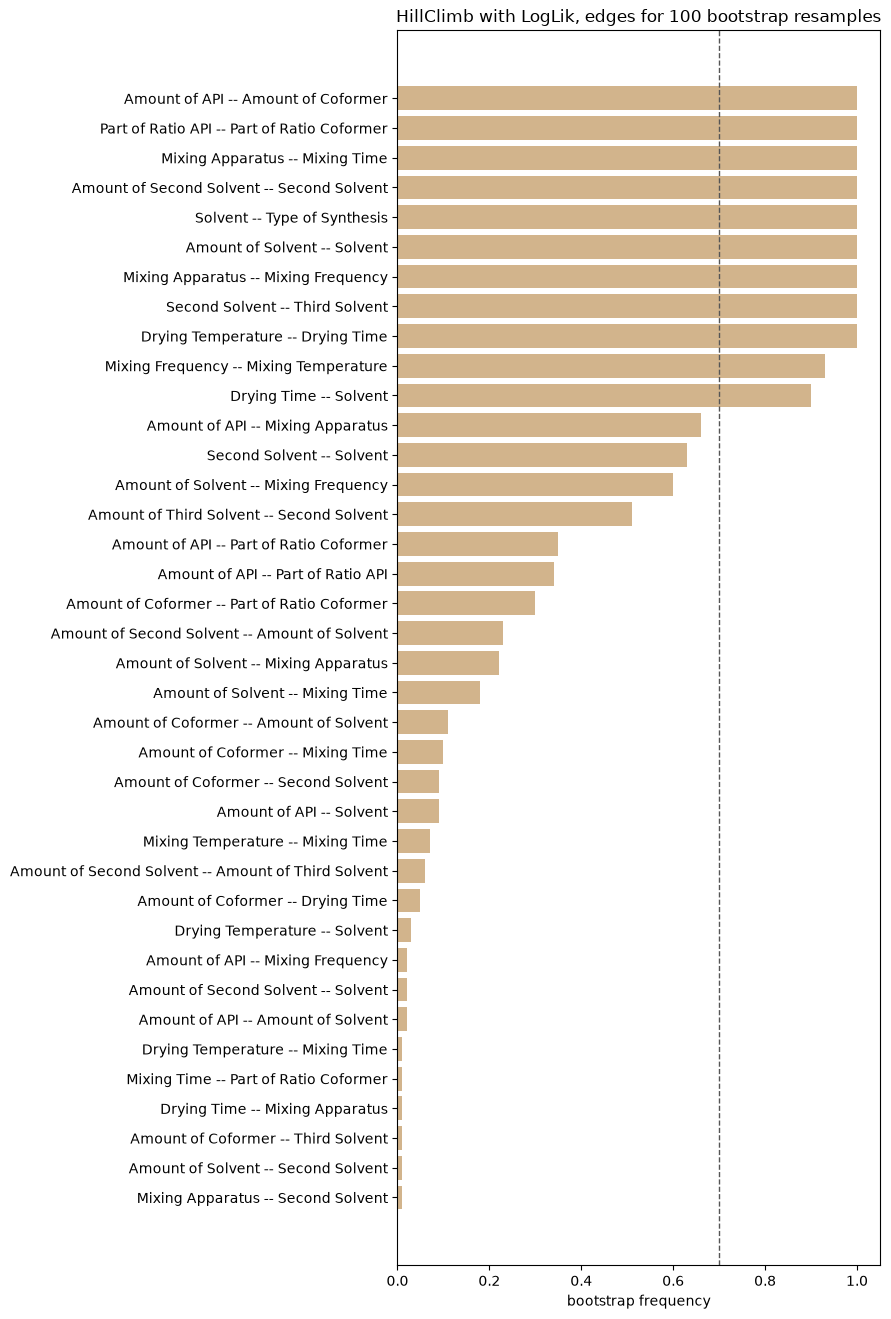

In [10]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(hc_ll_edges_table))))
labels = hc_ll_edges_table["V1"] + " -- " + hc_ll_edges_table["V2"]

ax.barh(labels, hc_ll_edges_table["frequency"], color="tan")
ax.invert_yaxis()
ax.set_xlabel("bootstrap frequency")
ax.set_title(f"HillClimb with LogLik, edges for {N_ITERATIONS_LL} bootstrap resamples")
ax.axvline(0.7, color="#555", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

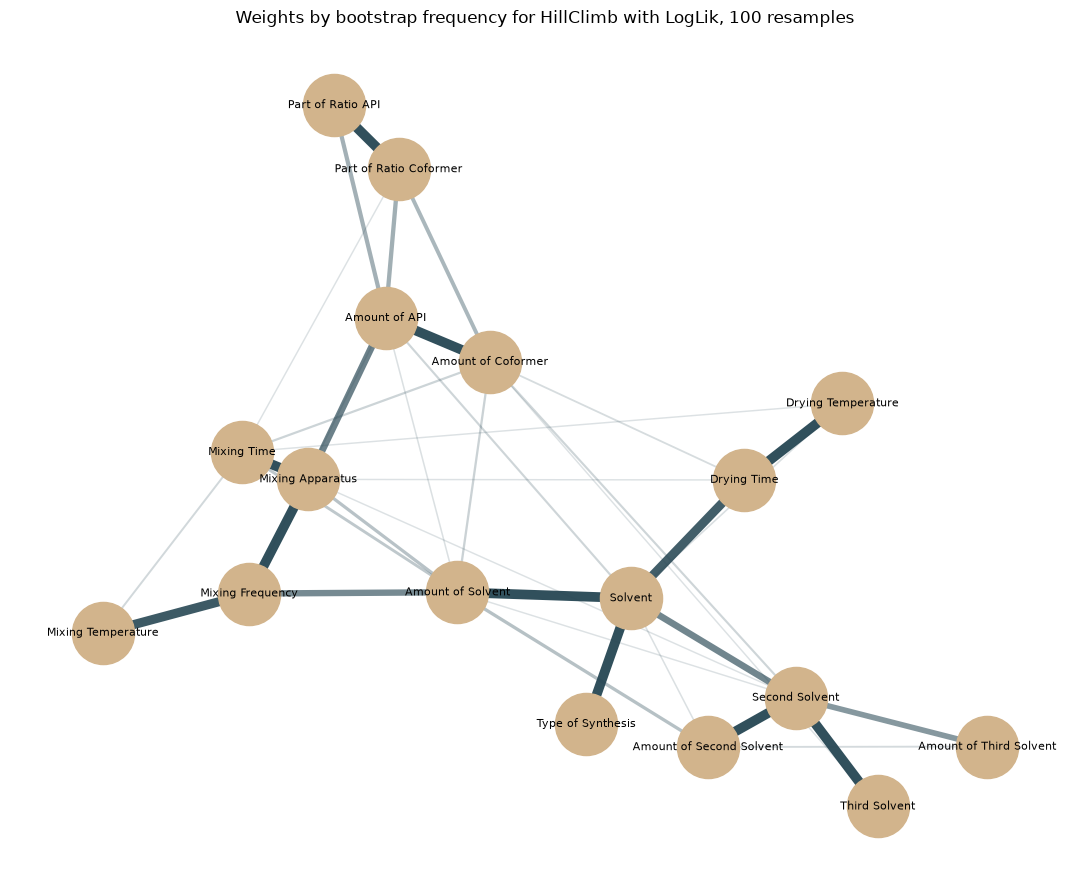

In [41]:
plot_bootstrap_graph(
    hc_ll_edges_table, random_state_addition=19191919, node_color="tan",
    title=f"Weights by bootstrap frequency for HillClimb with LogLik, {N_ITERATIONS_LL} resamples",
)

## Bootstrap: HillClimb with AIC

In [ ]:
N_ITERATIONS_AIC = 100

hc_aic_fit_fn = hillclimb_network_edge_fn(VARIABLE_COLUMNS, criterion='aic-d', max_parents=1)
hc_aic_edges_table = NetworkBootstrap(hc_ll_fit_fn, n_iterations=N_ITERATIONS_AIC).run(df_model)

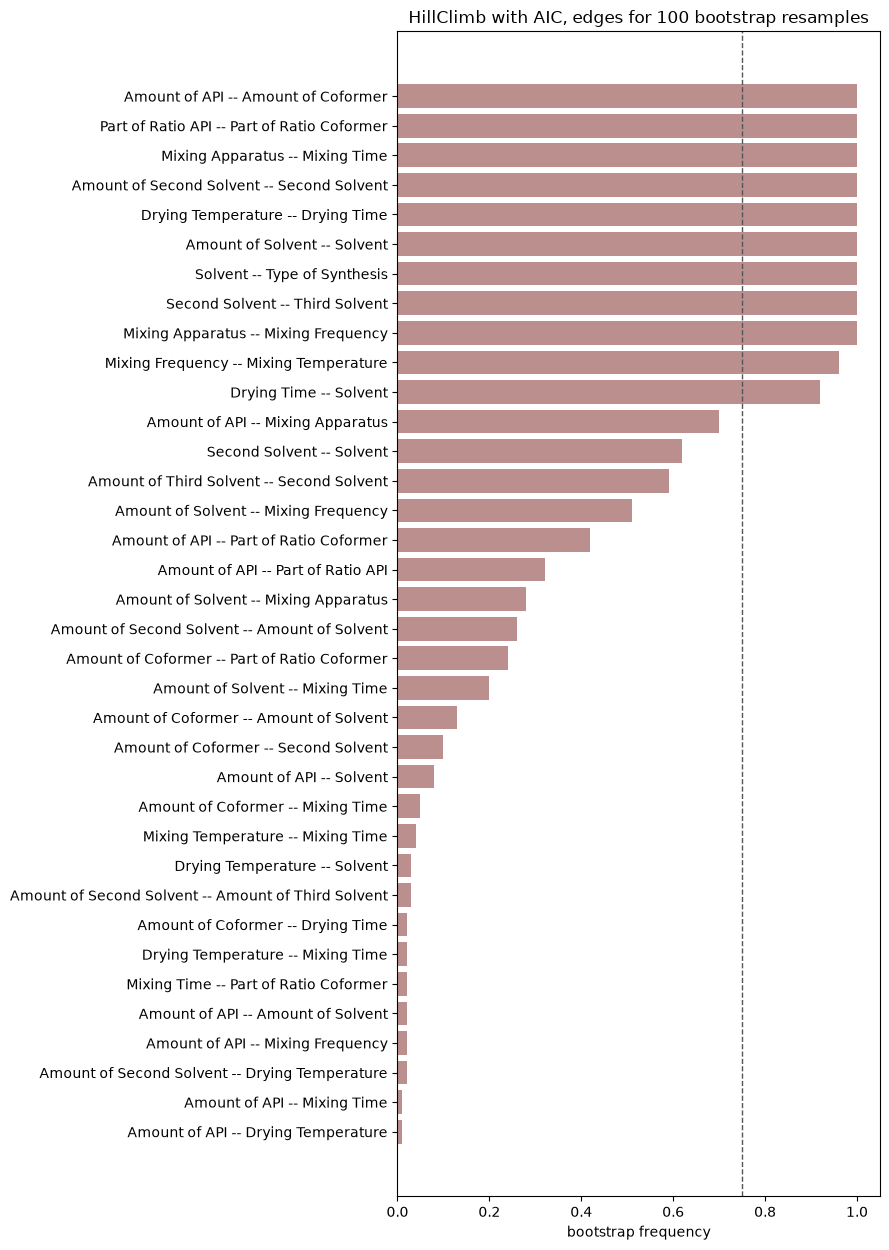

In [44]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(hc_aic_edges_table))))
labels = hc_aic_edges_table["V1"] + " -- " + hc_aic_edges_table["V2"]

ax.barh(labels, hc_aic_edges_table["frequency"], color="rosybrown")
ax.invert_yaxis()
ax.set_xlabel("bootstrap frequency")
ax.set_title(f"HillClimb with AIC, edges for {N_ITERATIONS_AIC} bootstrap resamples")
ax.axvline(0.75, color="#555", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

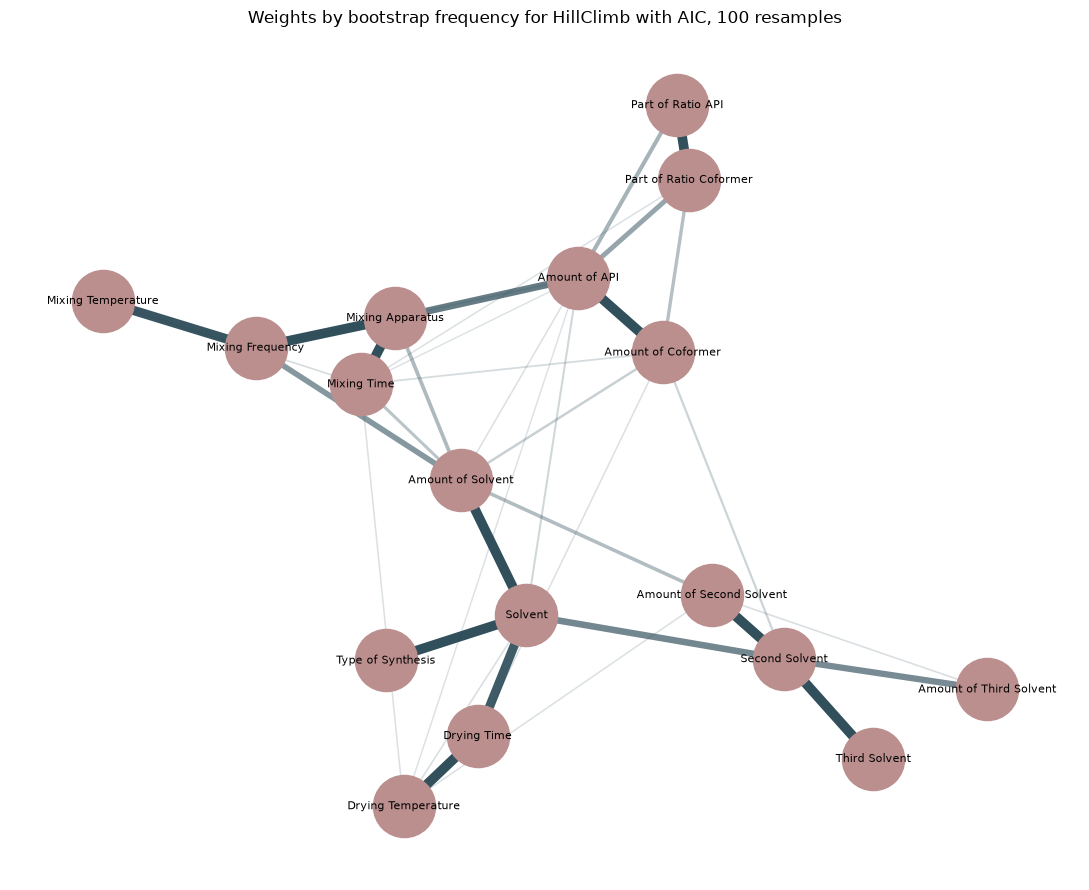

In [132]:
plot_bootstrap_graph(
    hc_aic_edges_table, random_state_addition=659940, node_color="rosybrown",
    title=f"Weights by bootstrap frequency for HillClimb with AIC, {N_ITERATIONS_AIC} resamples",
)